# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Timothy Tay
* Student ID: 2504524F


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [55]:
## import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

# 1. Business Understanding
Goal: ?

I want to help online laptop retailers set a fair price for new laptop models, just by using the laptop's specifications. Right now, staff have to manually search and compare similar laptops online to guess a reasonable price.This takes a lot of time and its inconsistent. If the price is too low then the retailer loses profit on every laptop sold. If the price is too high, the laptop becomes uncompetitive.

Machine learning framing:
- Task type: this is a regression problem, because the column being predicted is a continuous number, not a category like "cheap" or "expensive".
- Inputs: the laptop's specifications: brand, type, screen details, CPU, RAM, storage, GPU, operating system, and weight.
- Output: a predicted price that shows what similar laptops with these specs tend to sell for in the market.
- Why this matters for the business: instead of a staff member manually researching comparable
  listings for every single new laptop, the retailer can get an instant starting price, then adjust from there if needed based on business judgement.

# 2. Data Understanding

Overview: For data understanding i check data types, missing values and duplicates first because i need to know what to clean before i can build my mode, like ram and weight is text with units like "8GB" or "1.7KG". I know these need to be converted to numbers later. I also convert the price to SGD so its easier for me to read and also the business understanding is local retailer. 

## 2.1 Load dataset

In [56]:
## read *.csv file into pandas DataFrame
df_raw = pd.read_csv('laptop_data.csv', index_col=0)
df_raw.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


Dataset source: https://github.com/MAbdullahWaqar/Laptop_Price_predictor

This dataset contains 1,303 real laptop listings across 11 columns

In [57]:
## convert price from INR to SGD
INR_TO_SGD = 0.0134
df_raw['Price'] = df_raw['Price'] * INR_TO_SGD
df_raw['Price'].describe()

count    1303.000000
mean      802.258575
std       499.058904
min       124.227648
25%       427.657248
50%       697.531104
75%      1062.274902
max      4354.393248
Name: Price, dtype: float64

## 2.2 Summary Statistics

In [58]:
## understand the type of variable for each column
df_raw.dtypes

Company                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram                     str
Memory                  str
Gpu                     str
OpSys                   str
Weight                  str
Price               float64
dtype: object

In [59]:
## check for missing data
df_raw.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [60]:
## check for duplicate rows
df_raw.duplicated().sum()

np.int64(29)

In [61]:
## describe data distribution
df_raw.describe(include='all')

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1303,1303,1303.000000,1303,1303,1303,1303,1303,1303,1303,1303.000000
unique,19,6,NaN,40,118,9,39,110,9,179,NaN
top,Dell,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,297,727,NaN,507,190,619,412,281,1072,121,NaN
mean,NaN,NaN,15.017191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,802.258575
std,NaN,NaN,1.426304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,499.058904
min,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,124.227648
25%,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,427.657248
50%,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,697.531104
75%,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1062.274902


Observations:
- No missing values in any column.
- 29 exact duplicate rows exist.
- Ram and Weight are stored as text with units attached, so they need to be converted to plain numbers before any model can use them.
- ScreenResolution, Cpu, Memory, Gpu, and OpSys are free text columns of information together into one string.
- Price ranges from about 124.227648 to 4354.393248 with a mean of about 802.258575.

## 2.3 Data Visualization

Overview: I visualised the target distribution for checking whther price is normal distribution or skewed because it affects which model handles it better. It is right skewed and has outliers but the outliers are kept because its actual laptops and not data error. This shows that tree based models will be better than linear regression because its not thrown off by the skew. I also visualise the feature distribution and relationship ram vs price, typename vs price and correlation heatmap for sanity check that the data will be like the real world one before modelling.

### 2.3.1.1 Understanding distribution of target

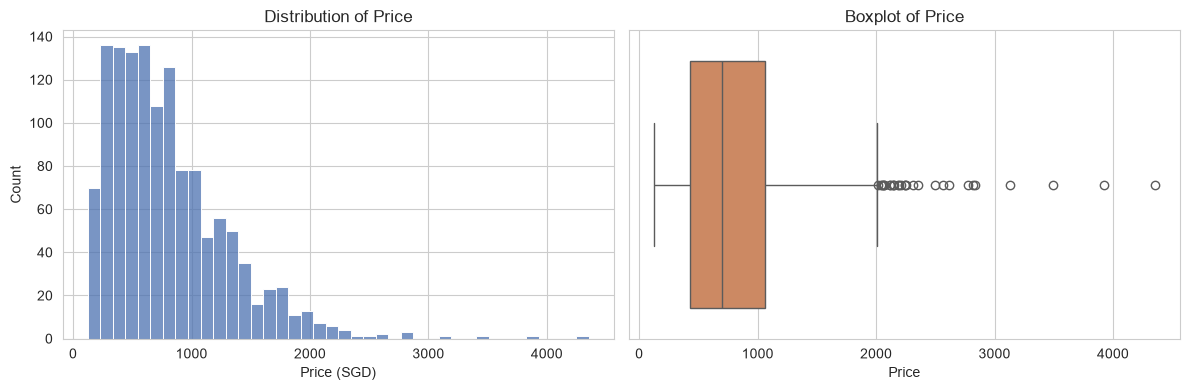

In [62]:
## understanding distribution of target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw['Price'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price (SGD)')
sns.boxplot(x=df_raw['Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot of Price')
plt.tight_layout()
plt.show()

Observation: the price is right skewed, most of the laptops are in the lower to mid price range with a long tail of higher priced laptops, this pulls the average above the middle value. The boxplot shows a few laptops sitting on top of the upper whisker. These are expensive premium or workstation laptops and not data entry errors so i keep them in the dataset and not remove. This is important because models like linear regression which fits a single straight line to all the data can be pulled off balance by the outliers but for tree models it will handle this kind of skew more naturally by splitting the data into groups instea of fitting one line.

### 2.3.1.2 Understanding distribution of features

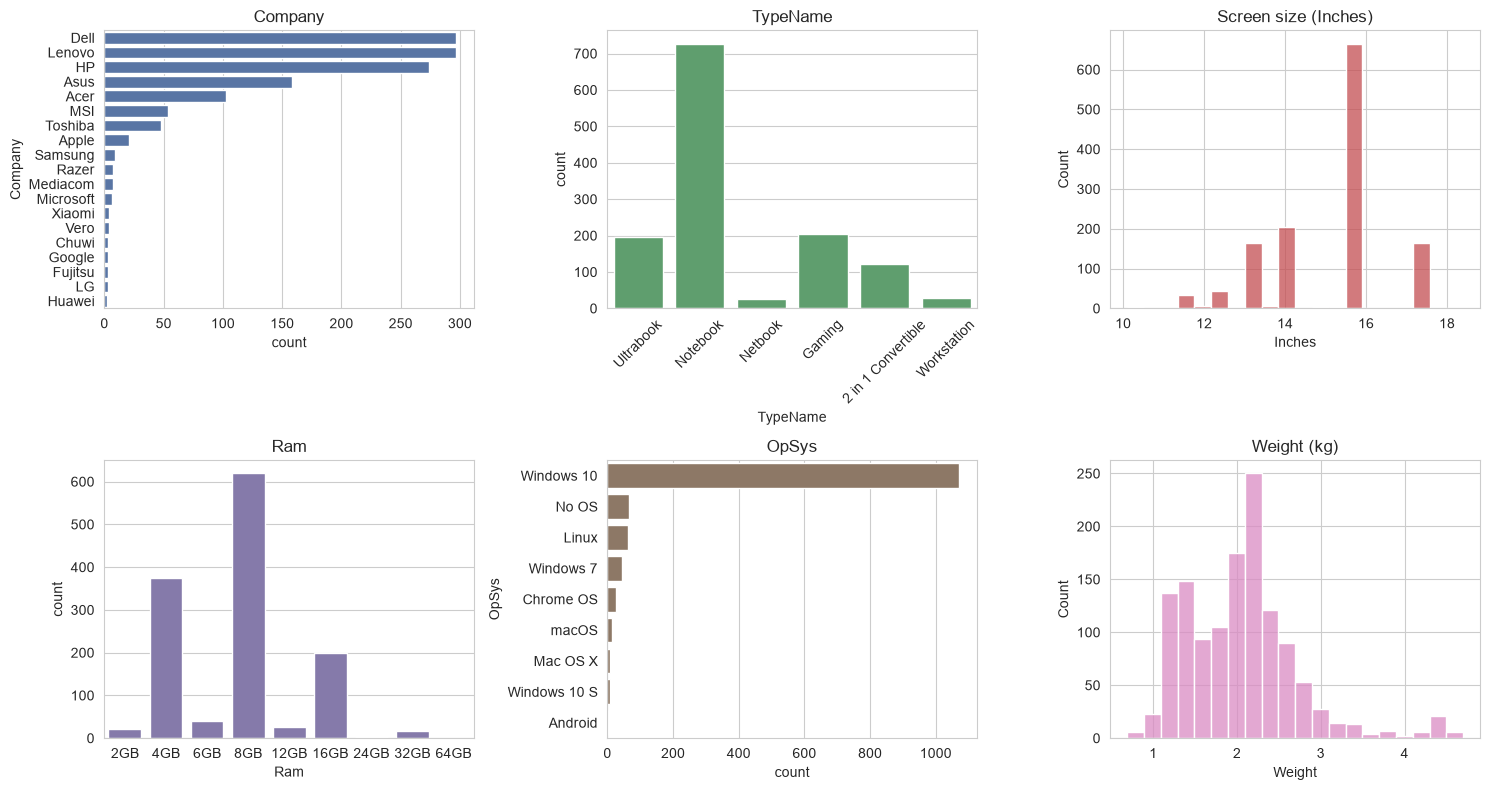

In [63]:
## understanding distribution of features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.countplot(y=df_raw['Company'], order=df_raw['Company'].value_counts().index, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Company')
sns.countplot(x=df_raw['TypeName'], ax=axes[0,1], color='#55A868')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_title('TypeName')
sns.histplot(df_raw['Inches'], bins=20, ax=axes[0,2], color='#C44E52')
axes[0,2].set_title('Screen size (Inches)')
sns.countplot(x=df_raw['Ram'], order=sorted(df_raw['Ram'].unique(), key=lambda x:int(x.replace('GB',''))),
              ax=axes[1,0], color='#8172B2')
axes[1,0].set_title('Ram')
sns.countplot(y=df_raw['OpSys'], order=df_raw['OpSys'].value_counts().index, ax=axes[1,1], color='#937860')
axes[1,1].set_title('OpSys')
weight_num = df_raw['Weight'].str.replace('kg','',regex=False).astype(float)
sns.histplot(weight_num, bins=20, ax=axes[1,2], color='#DA8BC3')
axes[1,2].set_title('Weight (kg)')
plt.tight_layout()
plt.show()

Observation: dell, lenovo and hp has the most in the dataset. Other brands like huawei, lg and chuwi only have a few listings. This matters later because brands with few examples are grouped into "other" category during feature engineering so the model and the one hot encoding no need to learn from catergories that barely have data to learn from. Notebook and ultrabook are the most common laptop types. Ram is the most at 4gb and 8gb which shows this is standard consumer laptop and not high end laptops. Windows has the most in the operating system which match the real world laptop market and its expected.

### 2.3.2 Understanding relationship between variables

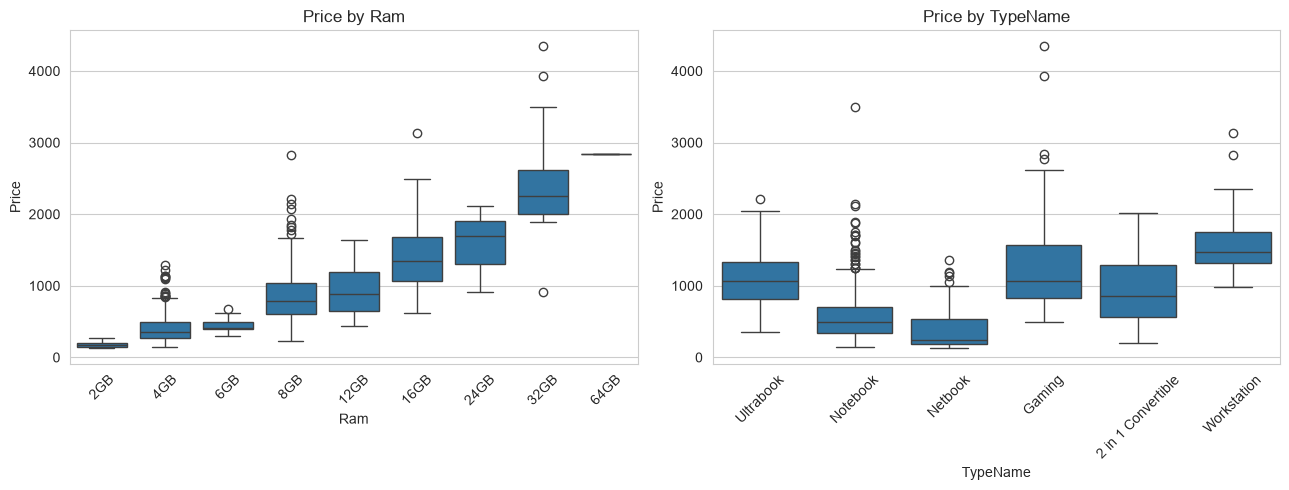

In [64]:
## understanding relationship between variables
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_raw, x='Ram', y='Price',
            order=sorted(df_raw['Ram'].unique(), key=lambda x:int(x.replace('GB',''))), ax=axes[0])
axes[0].set_title('Price by Ram')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=df_raw, x='TypeName', y='Price', ax=axes[1])
axes[1].set_title('Price by TypeName')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Observation: price rises with ram, and workstation and gaming laptop types cost more than netbooks and notebooks. It makes sense because more memory and higher performance cost more to build and sell.

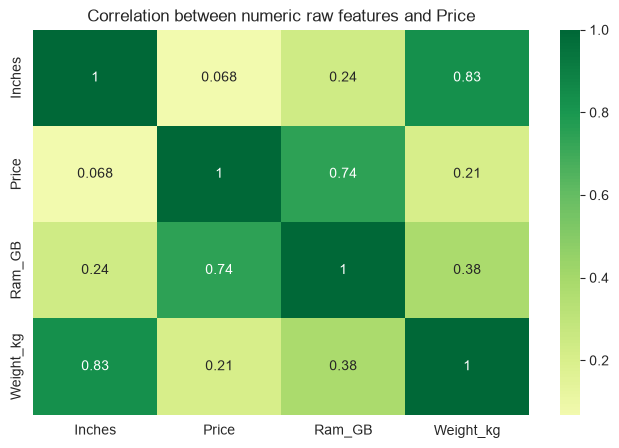

In [65]:
## plot heatmap
corr_check = df_raw[['Inches', 'Price']].copy()
corr_check['Ram_GB'] = df_raw['Ram'].str.replace('GB', '', regex=False).astype(int)
corr_check['Weight_kg'] = df_raw['Weight'].str.replace('kg', '', regex=False).astype(float)
sns.heatmap(corr_check.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation between numeric raw features and Price')
plt.show()

Observation: ram has a strong positive correlation with price, raw inches and weight are weakly correlated with price. All of these raw correlations are positive, the laptop price is based by the combination of the specs and not just one single part. 

# 3. Data Preparation

Overview: so i remove the duplicate row so that the model won't see the same listing two times and be biased for it. Then i convert ram and weight to numberic values since models cannot use text like "8GB". The free text columns are dropped to build the baseline feature set. OHE for company and typename then it will split into train and test with fixed random seed. This is for checking whether the model actually learns the underlying pattern instead of just memorising the laptops it was trained on. The data is also split 80/20 and it will be 80/20 for every split.

## 3.1 Data Cleaning

In [66]:
## clean data remove exact duplicate rows
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Removed {df_raw.duplicated().sum()} duplicate rows -> {df.shape[0]} rows remaining")

Removed 29 duplicate rows -> 1274 rows remaining


In [67]:
## convert ram and weight to numeric
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)
df[['Ram', 'Weight']].head()

,Ram,Weight
0,8,1.37
1,8,1.34
2,8,1.86
3,16,1.83
4,8,1.37


In [68]:
## drop the free text columns for now
df_c1 = df.drop(columns=['ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys'])
df_c1.head()

,Company,TypeName,Inches,Ram,Weight,Price
0,Apple,Ultrabook,13.3,8,1.37,956.474355
1,Apple,Ultrabook,13.3,8,1.34,641.800011
2,HP,Notebook,15.6,8,1.86,410.522400
3,Apple,Ultrabook,15.4,16,1.83,1811.617502
4,Apple,Ultrabook,13.3,8,1.37,1287.683827


## 3.2 Train-Test Split

In [69]:
## one hot encode the categorical columns used in the baseline
categorical_cols_c1 = ['Company', 'TypeName']
y_c1 = df_c1['Price']
X_c1 = pd.get_dummies(df_c1.drop(columns=['Price']), columns=categorical_cols_c1, drop_first=True)
print('Baseline feature count:', X_c1.shape[1])

Baseline feature count: 26


In [70]:
## split data into train set and test set
X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(X_c1, y_c1, test_size=0.2, random_state=42)
print('Train:', X_train_c1.shape, ' Test:', X_test_c1.shape)

Train: (1019, 26)  Test: (255, 26)


# 4. Modelling

Overview: for modelling i did a reusable evaluation function so every model is compared fairly and there is a baseline so i know if the model will improve later or not. I trained four different models, linear regression, decision tree, random forest and gradient boosting to see which model is the best one. Random forest has the best MAE so i tuned it with randomizedsearchcv. The same params will be used later for the iterations so the comparison will be fair and to see if the performance gets better.

## Baseline Models

In [71]:
## MAE, MSE, RMSE, R2
def evaluate_model(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error = y_pred - y_true
    ae = np.abs(error)
    se = error ** 2
    mae = np.mean(ae)
    mse = np.mean(se)
    rmse = np.sqrt(mse)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f"{label:30s} MAE={mae:10,.1f}  MSE={mse:14,.1f}  RMSE={rmse:10,.1f}  R2={r2:.4f}")
    return {'model': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [72]:
## baseline predict the mean training price
results = []
baseline_pred = np.full(shape=len(y_test_c1), fill_value=y_train_c1.mean())
results.append(evaluate_model(y_test_c1, baseline_pred, 'Baseline (mean price)'))

Baseline (mean price)          MAE=     384.5  MSE=     309,681.1  RMSE=     556.5  R2=-0.0064


### 4.1 Train Model

In [73]:
## linear regression
lr = LinearRegression()
lr.fit(X_train_c1, y_train_c1)
results.append(evaluate_model(y_test_c1, lr.predict(X_test_c1), 'Linear Regression'))

Linear Regression              MAE=     223.1  MSE=     104,127.2  RMSE=     322.7  R2=0.6616


In [74]:
## decision tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_c1, y_train_c1)
results.append(evaluate_model(y_test_c1, dt.predict(X_test_c1), 'Decision Tree'))

Decision Tree                  MAE=     182.1  MSE=      97,211.7  RMSE=     311.8  R2=0.6841


In [75]:
## random forest
rf_c1 = RandomForestRegressor(random_state=42)
rf_c1.fit(X_train_c1, y_train_c1)
results.append(evaluate_model(y_test_c1, rf_c1.predict(X_test_c1), 'Random Forest'))

Random Forest                  MAE=     171.3  MSE=      75,157.6  RMSE=     274.1  R2=0.7557


In [76]:
## gradient boosting
gb_c1 = GradientBoostingRegressor(random_state=42)
gb_c1.fit(X_train_c1, y_train_c1)
results.append(evaluate_model(y_test_c1, gb_c1.predict(X_test_c1), 'Gradient Boosting'))

Gradient Boosting              MAE=     190.3  MSE=      80,487.4  RMSE=     283.7  R2=0.7384


In [77]:
## compare baseline models
results_df = pd.DataFrame(results).set_index('model')
results_df

,MAE,MSE,RMSE,R2
model,,,,
Baseline (mean price),384.505631,309681.114211,556.489995,-0.006415
Linear Regression,223.096511,104127.214823,322.687488,0.661603
Decision Tree,182.076258,97211.685817,311.787886,0.684077
Random Forest,171.287310,75157.560178,274.148792,0.755750
Gradient Boosting,190.310753,80487.394869,283.703005,0.738429


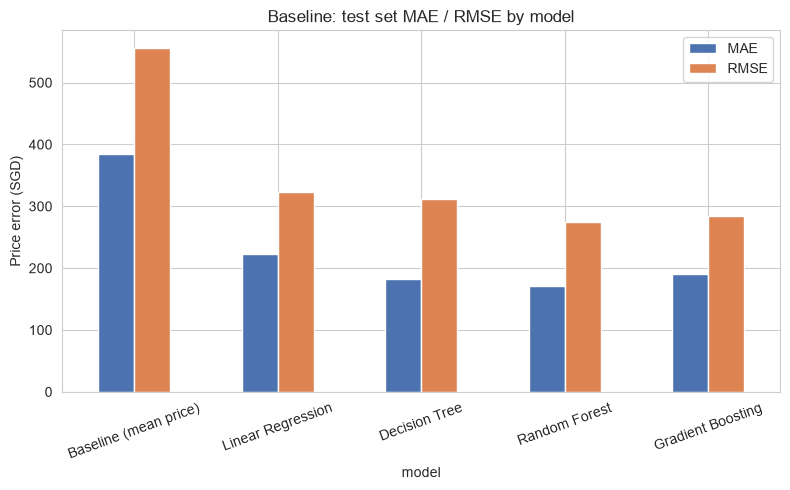

In [78]:
## visualise the comparison
results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#DD8452'])
plt.title('Baseline: test set MAE / RMSE by model')
plt.ylabel('Price error (SGD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Observation: all four model beat the mean price baseline. linear regression is the weakest, since the price relationship is not linear so the straight line will struggle. Random forest gives the lowest MAE and highest R2, so its chosen as the baseline best model.

### 4.2 Hyperparameter Tuning

In [79]:
## tune decision tree
dt_params = {'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
dt_search = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), dt_params, n_iter=10, cv=5,
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
dt_search.fit(X_train_c1, y_train_c1)
print('Decision Tree best hyperparameters:', dt_search.best_params_)
results.append(evaluate_model(y_test_c1, dt_search.best_estimator_.predict(X_test_c1), 'Decision Tree (tuned)'))

Decision Tree best hyperparameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
Decision Tree (tuned)          MAE=     187.1  MSE=      84,869.3  RMSE=     291.3  R2=0.7242


In [80]:
## tune random forest
param_distributions = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
}
random_search_baseline = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
random_search_baseline.fit(X_train_c1, y_train_c1)
print('Random Forest best hyperparameters found:', random_search_baseline.best_params_)
best_rf_baseline = random_search_baseline.best_estimator_
best_rf_baseline_pred = best_rf_baseline.predict(X_test_c1)
results.append(evaluate_model(y_test_c1, best_rf_baseline_pred, 'Baseline: Random Forest (tuned)'))

Random Forest best hyperparameters found: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 20}
Baseline: Random Forest (tuned) MAE=     170.9  MSE=      75,827.7  RMSE=     275.4  R2=0.7536


In [81]:
## tune gradient boosting
gb_params = {'n_estimators': [100, 300, 500], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
gb_search = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), gb_params, n_iter=10, cv=5,
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
gb_search.fit(X_train_c1, y_train_c1)
print('Gradient Boosting best hyperparameters:', gb_search.best_params_)
results.append(evaluate_model(y_test_c1, gb_search.best_estimator_.predict(X_test_c1), 'Gradient Boosting (tuned)'))

Gradient Boosting best hyperparameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1}
Gradient Boosting (tuned)      MAE=     182.7  MSE=      85,807.9  RMSE=     292.9  R2=0.7211


In [82]:
## compare all tuned models
tuned_results_df = pd.DataFrame(results).set_index('model')
tuned_rows = ['Decision Tree (tuned)', 'Baseline: Random Forest (tuned)', 'Gradient Boosting (tuned)']
tuned_results_df.loc[tuned_rows]

,MAE,MSE,RMSE,R2
model,,,,
Decision Tree (tuned),187.120410,84869.314096,291.323384,0.724188
Baseline: Random Forest (tuned),170.903323,75827.721091,275.368337,0.753572
Gradient Boosting (tuned),182.712509,85807.856651,292.929781,0.721138


# 5. Model Evaluation

Overview: this is to check the tuned baseline random forest performance again and try on new data for sanity check to make sure the prediction looks real on something the model never see before and not just a good number. I choose random forest over the other models because it gives the lowest MAE everytime for baseline tuned. It also fits this problem because laptop pricing is not a straight line relationship, extra gb of ram won't add the same dollar amount at every price point so the linear regression won't perform well since it can only fit on straight line. Random forest also build many decision trees that each split the data into groups which will naturally handle the right skewed price distribution and the other outlier laptops without distorting the whole model. It also won't just give a random price, it can show which specification matter the most forthe price which is useful for a retailer.

In [83]:
## evaluate model the baseline's best model, tuned Random Forest
cycle1_eval = evaluate_model(y_test_c1, best_rf_baseline_pred, 'Baseline best (Random Forest, tuned)')

Baseline best (Random Forest, tuned) MAE=     170.9  MSE=      75,827.7  RMSE=     275.4  R2=0.7536


In [84]:
## new data
new_laptop_c1 = pd.DataFrame([{
    'Inches': 15.6, 'Ram': 16, 'Weight': 2.1,
    'Company': 'Dell', 'TypeName': 'Notebook'
}])
new_laptop_c1_enc = pd.get_dummies(new_laptop_c1, columns=categorical_cols_c1, drop_first=True)
new_laptop_c1_enc = new_laptop_c1_enc.reindex(columns=X_train_c1.columns, fill_value=0)

## Predict
cycle1_new_pred = best_rf_baseline.predict(new_laptop_c1_enc)[0]
print(f"Baseline predicted price for the new laptop: {cycle1_new_pred:,}")

Baseline predicted price for the new laptop: 1,237.5796410917706


## Iterative model development

## Iteration 1: Feature engineering and hyperparameter tuning

Overview: For iter 1 i make the dropped free text column into real features from the baseline like screen resolution split into touchscreen, ips and ppi then cpu split into brand and clock speed and for memory split into hdd, ssd hybrid and flash storage. Gpu is simplified down to brand, opsys grouped into 4 categories and the rare brands grouped into "other" so the OHE won't create near empty noise columns. I did this because these columns carry pricing signal that a raw text string can't give to the model directly. After that i re-encode and re-split the data with the same as the baseline model so its fair then retrain on random forest which is my best model from baseline and tune it with the randomizedsearchcv with the same params as baseline. The results got better, for MAE it improved from 170.903323 to 139.438170 because of the feature engineering so i will use the model for iteration 2.

### Feature engineering

Feature engineering screen resolution: screen resolution combine panel type, touchscreen and pixel resolution into one free text string. This is split into Touchscreen, IPS and PPI.

In [85]:
## engineer screen related features
df_c2 = df.copy()
df_c2['Touchscreen'] = df_c2['ScreenResolution'].str.contains('Touchscreen').astype(int)
df_c2['IPS'] = df_c2['ScreenResolution'].str.contains('IPS Panel').astype(int)
res = df_c2['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
x_res = res[0].astype(int)
y_res = res[1].astype(int)
df_c2['PPI'] = (((x_res ** 2) + (y_res ** 2)) ** 0.5 / df_c2['Inches']).astype(float)
df_c2[['Touchscreen', 'IPS', 'PPI']].describe()

,Touchscreen,IPS,PPI
count,1274.000000,1274.000000,1274.000000
mean,0.147567,0.280220,147.019538
std,0.354809,0.449283,42.979971
min,0.000000,0.000000,90.583402
25%,0.000000,0.000000,127.335675
50%,0.000000,0.000000,141.211998
75%,0.000000,1.000000,157.350512
max,1.000000,1.000000,352.465147


Feature engineering CPU: cpu mix brand, tier and clock speed in one string. This is split into cpu brand and cpu speed.

In [86]:
## engineer cpu related features
def get_cpu_brand(cpu_text):
    core = ' '.join(cpu_text.split()[:3])
    if core in ('Intel Core i7', 'Intel Core i5', 'Intel Core i3'):
        return core
    elif cpu_text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

df_c2['Cpu brand'] = df_c2['Cpu'].apply(get_cpu_brand)
df_c2['Cpu speed (GHz)'] = df_c2['Cpu'].str.extract(r'([\d.]+)GHz').astype(float)
df_c2['Cpu brand'].value_counts()

Cpu brand
Intel Core i7            515
Intel Core i5            423
Other Intel Processor    141
Intel Core i3            134
AMD Processor             61
Name: count, dtype: int64

Feature engineering memory: memory sometimes list up to two storage device in one string. This is split into 4 columns, hdd, ssd, hybrid and flash storage. All of it will be in GB because ssd cost more per GB than hdd, so keeping them separate let the model learn the difference.

In [87]:
## engineer memory features
def parse_memory(mem_text):
    mem_text = mem_text.replace('GB', '').replace('TB', '000')
    hdd = ssd = hybrid = flash = 0.0
    for part in mem_text.split('+'):
        part = part.strip()
        amount = float(re.findall(r'[\d.]+', part)[0])
        if 'SSD' in part:
            ssd += amount
        elif 'HDD' in part:
            hdd += amount
        elif 'Hybrid' in part:
            hybrid += amount
        elif 'Flash' in part:
            flash += amount
    return pd.Series([hdd, ssd, hybrid, flash])

df_c2[['HDD', 'SSD', 'Hybrid', 'Flash_Storage']] = df_c2['Memory'].apply(parse_memory)
df_c2[['HDD', 'SSD', 'Hybrid', 'Flash_Storage']].describe()

,HDD,SSD,Hybrid,Flash_Storage
count,1274.000000,1274.000000,1274.000000,1274.000000
mean,412.606750,186.106750,0.405808,4.508634
std,517.848085,186.531295,14.232477,30.500079
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,256.000000,0.000000,0.000000
75%,1000.000000,256.000000,0.000000,0.000000
max,2000.000000,1024.000000,508.000000,512.000000


Feature engineering GPU and OPSYS: gpu is simplified to gpu brand and opsys is grouped into os with 4 category, windows, mac, no os and linux/other. This is because the original column has 9 near duplicate like windows 10 and windows 10s

In [88]:
## engineer gpu and opsys features
df_c2['Gpu brand'] = df_c2['Gpu'].apply(lambda x: x.split()[0])
df_c2['Gpu brand'] = df_c2['Gpu brand'].replace({'ARM': 'Other'})

def group_os(os_text):
    os_lower = os_text.lower()
    if 'windows' in os_lower:
        return 'Windows'
    elif 'mac' in os_lower:
        return 'Mac'
    elif os_text == 'No OS':
        return 'No OS'
    else:
        return 'Linux/Other'

df_c2['os'] = df_c2['OpSys'].apply(group_os)
df_c2[['Gpu brand', 'os']].apply(pd.Series.value_counts)

,Gpu brand,os
AMD,174.0,NaN
Intel,703.0,NaN
Linux/Other,NaN,87.0
Mac,NaN,21.0
No OS,NaN,66.0
Nvidia,396.0,NaN
Other,1.0,NaN
Windows,NaN,1100.0


Feature engineering rare brands: some company has brands with fewer than 10 listings. These are grouped into other so the model and OHE does not create noisy empty column for brands with almost no data

In [89]:
## group rare company
company_counts = df_c2['Company'].value_counts()
rare_companies = company_counts[company_counts < 10].index.tolist()
print('Grouped into Other:', rare_companies)
df_c2['Company'] = df_c2['Company'].apply(lambda c: 'Other' if c in rare_companies else c)

Grouped into Other: ['Samsung', 'Razer', 'Mediacom', 'Microsoft', 'Xiaomi', 'Vero', 'Chuwi', 'Google', 'Fujitsu', 'LG', 'Huawei']


In [90]:
## drop the original free text columns now
df_c2 = df_c2.drop(columns=['ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys'])
df_c2.head()

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,Cpu brand,Cpu speed (GHz),HDD,SSD,Hybrid,Flash_Storage,Gpu brand,os
0,Apple,Ultrabook,13.3,8,1.37,956.474355,0,1,226.983005,Intel Core i5,2.3,0.0,128.0,0.0,0.0,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,641.800011,0,0,127.677940,Intel Core i5,1.8,0.0,0.0,0.0,128.0,Intel,Mac
2,HP,Notebook,15.6,8,1.86,410.522400,0,0,141.211998,Intel Core i5,2.5,0.0,256.0,0.0,0.0,Intel,No OS
3,Apple,Ultrabook,15.4,16,1.83,1811.617502,0,1,220.534624,Intel Core i7,2.7,0.0,512.0,0.0,0.0,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,1287.683827,0,1,226.983005,Intel Core i5,3.1,0.0,256.0,0.0,0.0,Intel,Mac


In [91]:
## final check no missing values were introduced during feature engineering
df_c2.isna().sum().sum()

np.int64(0)

### Data prep for updated feature

In [92]:
## one hot encode the categorical columns used from iter1
categorical_cols_c2 = ['Company', 'TypeName', 'Cpu brand', 'Gpu brand', 'os']
y_c2 = df_c2['Price']
X_c2 = pd.get_dummies(df_c2.drop(columns=['Price']), columns=categorical_cols_c2, drop_first=True)
print('Iteration 1 feature count:', X_c2.shape[1])

Iteration 1 feature count: 34


In [93]:
## split feature engineered data into training and test sets
X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(X_c2, y_c2, test_size=0.2, random_state=42)
print('Train:', X_train_c2.shape, ' Test:', X_test_c2.shape)

Train: (1019, 34)  Test: (255, 34)


### Random forest with engineered feature

In [94]:
## retrain the baseline's best model on the engineered features
rf_c2 = RandomForestRegressor(random_state=42)
rf_c2.fit(X_train_c2, y_train_c2)
rf_c2_pred = rf_c2.predict(X_test_c2)
results.append(evaluate_model(y_test_c2, rf_c2_pred, 'Iteration 1: Random Forest (feature engineered)'))

Iteration 1: Random Forest (feature engineered) MAE=     139.1  MSE=      56,332.2  RMSE=     237.3  R2=0.8169


### Hyperparameter tuning

In [95]:
## tune random forest hyperparameters
random_search_1 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
random_search_1.fit(X_train_c2, y_train_c2)
print('Iteration 1 best hyperparameters found:', random_search_1.best_params_)

Iteration 1 best hyperparameters found: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 20}


In [96]:
## extract the tuned model and evaluate it on the test set
best_rf_1 = random_search_1.best_estimator_
best_rf_1_pred = best_rf_1.predict(X_test_c2)
results.append(evaluate_model(y_test_c2, best_rf_1_pred, 'Iteration 1: Random Forest (tuned)'))

Iteration 1: Random Forest (tuned) MAE=     139.4  MSE=      56,462.7  RMSE=     237.6  R2=0.8165


### Comparison for baseline and iter1

In [97]:
## compare baseline and iter 1
comparison_iter1 = pd.DataFrame(results).set_index('model')
rf_rows = ['Baseline: Random Forest (tuned)', 'Iteration 1: Random Forest (feature engineered)',
           'Iteration 1: Random Forest (tuned)']
comparison_iter1.loc[rf_rows]

,MAE,MSE,RMSE,R2
model,,,,
Baseline: Random Forest (tuned),170.903323,75827.721091,275.368337,0.753572
Iteration 1: Random Forest (feature engineered),139.104712,56332.218314,237.344093,0.816929
Iteration 1: Random Forest (tuned),139.438170,56462.677636,237.618765,0.816505


Observation: random forest improves for MAE from 170.903323 to 139.438170. It is still the best model so it will be used for iteration 2

## Iteration 2: Feature Importance, Feature Selection and Hyperparameter Tuning

Overview: for iter 2 i checked feature importance on the iter 1 model to see whether all 34 features are actually making the model good or if some are just adding noise. I plot a feature importance with cumulative importance graph and found that ram, weight, ppi, cpu speed and ssd have the most weight in the models decision so i chose the smallest set of features that cover 90% if the cumulative importance and retrain and tune random forest on that 9 features to see whether a simpler model can be better than iter 1 model or get close to it. Iter 2 model came close to iter 1 model but did not beat it which shows that a simpler model is viable but not better so iter 1 model is used for the final model and tested one more time on new data before saving it.

### Feature importance

In [98]:
## calculate feature importance from iter 1 tuned random forest
importances = pd.Series(best_rf_1.feature_importances_, index=X_train_c2.columns).sort_values(ascending=False)
importances.head(12)

Ram                        0.536458
Weight                     0.133167
PPI                        0.052130
Cpu speed (GHz)            0.050165
SSD                        0.039581
TypeName_Notebook          0.034759
TypeName_Workstation       0.019950
Inches                     0.017291
Cpu brand_Intel Core i7    0.017214
Cpu brand_Intel Core i5    0.015990
Company_Other              0.009218
Touchscreen                0.007251
dtype: float64

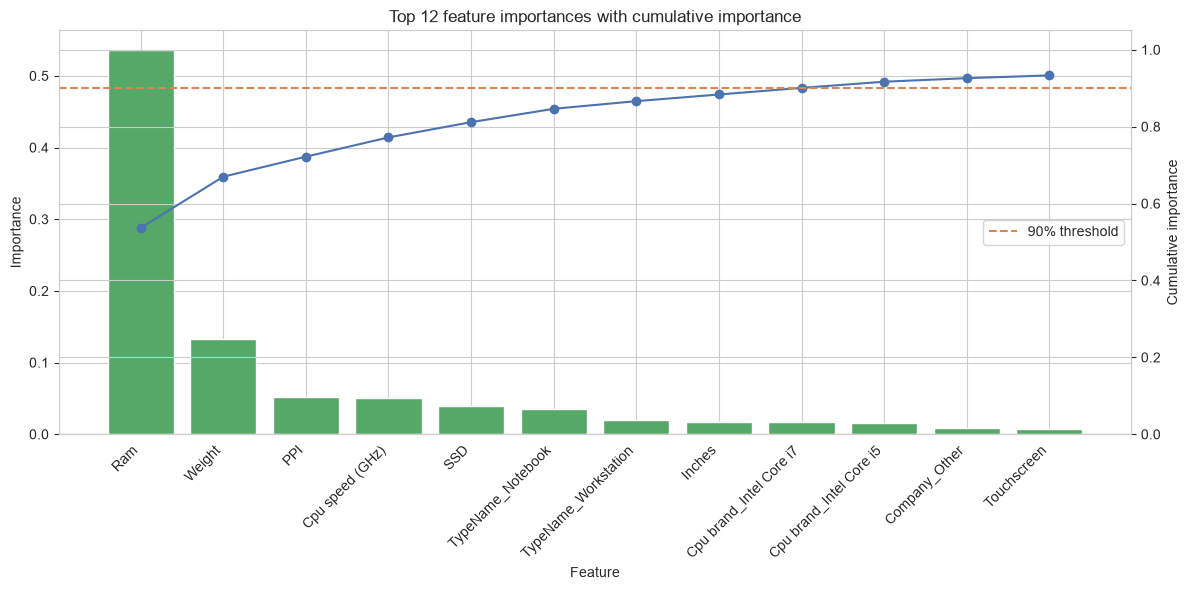

In [99]:
## plot feature importance
cumulative_importance = importances.cumsum()
top_n = importances.head(12)
top_cumulative = cumulative_importance.head(12)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(range(len(top_n)), top_n.values, color='#55A868')
ax1.set_xticks(range(len(top_n)))
ax1.set_xticklabels(top_n.index, rotation=45, ha='right')
ax1.set_ylabel('Importance')
ax1.set_xlabel('Feature')
ax1.set_title('Top 12 feature importances with cumulative importance')
ax2 = ax1.twinx()
ax2.plot(range(len(top_n)), top_cumulative.values, color='#4C72B0', marker='o')
ax2.axhline(0.9, color='#DD8452', linestyle='--', label='90% threshold')
ax2.set_ylabel('Cumulative importance')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='center right')
plt.tight_layout()
plt.show()

Observation: ram, weight, ppi, cpu speed and ssd capacity is the strongest price drivers. 9 features combine is 90 percent of the models feature importance, this means the OHE columns individually contribute very little.

### B. Feature selection

In [100]:
## select the smallest set of features that is 90 percent cumulative importance
n_features_90 = (cumulative_importance < 0.90).sum() + 1
selected_features = importances.head(n_features_90).index.tolist()
print(f"Selected {n_features_90} features out of {len(importances)}:")
print(selected_features)

Selected 9 features out of 34:
['Ram', 'Weight', 'PPI', 'Cpu speed (GHz)', 'SSD', 'TypeName_Notebook', 'TypeName_Workstation', 'Inches', 'Cpu brand_Intel Core i7']


### C. Data prep for selected features

In [101]:
## keep only the selected features in both the training and test sets
X_train_sel = X_train_c2[selected_features]
X_test_sel = X_test_c2[selected_features]
print('Selected feature count:', X_train_sel.shape[1])

Selected feature count: 9


### D. random forest with selected features

In [102]:
## retrain random forest using only the selected features
rf_sel = RandomForestRegressor(random_state=42)
rf_sel.fit(X_train_sel, y_train_c2)
rf_sel_pred = rf_sel.predict(X_test_sel)
results.append(evaluate_model(y_test_c2, rf_sel_pred, 'Iteration 2: Random Forest (selected features)'))

Iteration 2: Random Forest (selected features) MAE=     150.2  MSE=      56,794.7  RMSE=     238.3  R2=0.8154


### E. Hyperparameter tuning

In [103]:
## tune random forest hyperparameters
random_search_2 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
random_search_2.fit(X_train_sel, y_train_c2)
print('Iteration 2 best hyperparameters found:', random_search_2.best_params_)

Iteration 2 best hyperparameters found: {'n_estimators': 500, 'min_samples_split': 10, 'max_depth': 20}


In [104]:
## extract the tuned model and evaluate it on the test set
best_rf_2 = random_search_2.best_estimator_
best_rf_2_pred = best_rf_2.predict(X_test_sel)
results.append(evaluate_model(y_test_c2, best_rf_2_pred, 'Iteration 2: Random Forest (tuned, selected features)'))

Iteration 2: Random Forest (tuned, selected features) MAE=     153.9  MSE=      70,060.5  RMSE=     264.7  R2=0.7723


### Comparison of baseline iter 1 and iter 2

In [105]:
## compare only the random forest
comparison_all = pd.DataFrame(results).set_index('model')
rf_rows = ['Baseline: Random Forest (tuned)',
           'Iteration 1: Random Forest (feature engineered)',
           'Iteration 1: Random Forest (tuned)',
           'Iteration 2: Random Forest (selected features)',
           'Iteration 2: Random Forest (tuned, selected features)']
comparison_all.loc[rf_rows]

,MAE,MSE,RMSE,R2
model,,,,
Baseline: Random Forest (tuned),170.903323,75827.721091,275.368337,0.753572
Iteration 1: Random Forest (feature engineered),139.104712,56332.218314,237.344093,0.816929
Iteration 1: Random Forest (tuned),139.438170,56462.677636,237.618765,0.816505
Iteration 2: Random Forest (selected features),150.215159,56794.671098,238.316326,0.815426
"Iteration 2: Random Forest (tuned, selected features)",153.859393,70060.492929,264.689427,0.772314


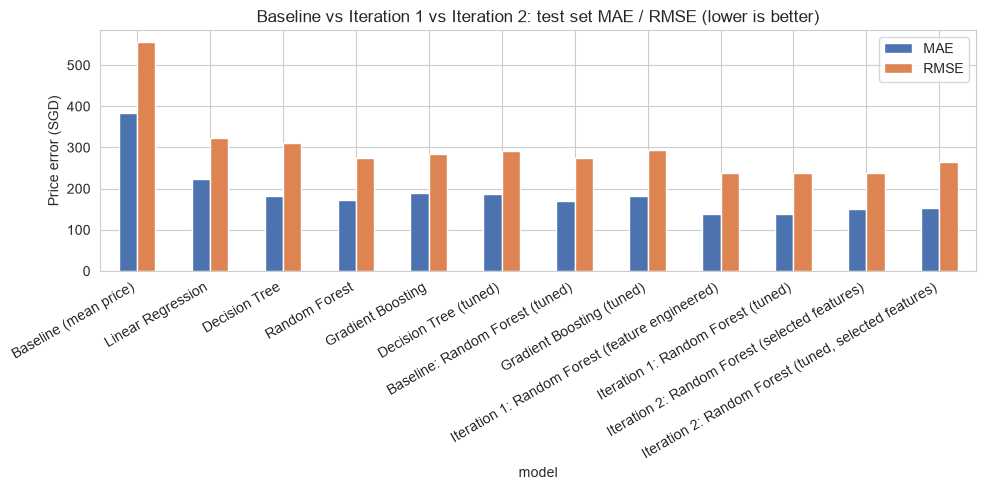

In [106]:
## visualise every model tried so far
comparison_all[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 5), color=['#4C72B0', '#DD8452'])
plt.title('Baseline vs Iteration 1 vs Iteration 2: test set MAE / RMSE (lower is better)')
plt.ylabel('Price error (SGD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Observation: MAE is the metric because it is measured in the same unit as price, it is also less affected by the outlier laptops. MAE also dont square the error before averaging them. For iter 1 tuned random forest gives the best result of all 3 with only 139.438170 sgd average error. This shows that the feature engineering in iter 1 works and makes the model usable for predicting the price of laptops. For iter 2 its worse than iter 1 but not far off using only 9 of the 34 features, re tuning on the smaller feature set did not help also, the tune model is 153.859393 compared to untuned which is 150.215159 which did not help the model, this is the same case for iter 1 also. This is still useful information because it shows that a more simple model using fewer features still comes close to a model using more features. Which makes it useful if simpler and faster model is preferred but since iter 1 has the lowest MAE out of all 3 models it is used because it minimises to average dollar error and its better for a business because they care about the money.

## New data

In [107]:
## new data
new_laptop_final = pd.DataFrame([{
    'Inches': 15.6, 'Ram': 16, 'Weight': 2.1, 'Touchscreen': 0, 'IPS': 1, 'PPI': 141.2,
    'Cpu speed (GHz)': 2.6, 'HDD': 0, 'SSD': 512, 'Hybrid': 0, 'Flash_Storage': 0,
    'Company': 'Dell', 'TypeName': 'Notebook', 'Cpu brand': 'Intel Core i7',
    'Gpu brand': 'Nvidia', 'os': 'Windows'
}])
new_laptop_final_enc = pd.get_dummies(new_laptop_final, columns=categorical_cols_c2, drop_first=True)
new_laptop_final_enc = new_laptop_final_enc.reindex(columns=X_train_c2.columns, fill_value=0)

## Predict
final_new_pred = best_rf_1.predict(new_laptop_final_enc)[0]
print(f"Final model predicted price for the new laptop: {final_new_pred:,}")

Final model predicted price for the new laptop: 1,167.6809142151042


## Summary

| Stage | Features | Model | MAE | RMSE | R2 |
|---|---|---|---|---|---|
| Baseline (tuned) | Brand, type, screen, RAM, weight only | Random Forest (tuned) | 170.903323 | 275.368337 | 0.753572 |
| Iteration 1 (feature engineered, tuned) | Adds display, CPU, GPU, OS, storage split (34 features) | Random Forest (tuned) | 139.438170 | 237.618765 | 0.816505 |
| Iteration 2 (feature selected, tuned) | Top 9 features by importance | Random Forest (tuned) | 153.859393 | 264.689427 | 0.772314 |

All the models are hypertune with the same split so that the comparison is fair. This shows that improvement all comes from feature engineering and not extra tunes, iter 1 improves from the tuned baseline, MAE drops from 170.903323 to 139.438170 becuase of the feature engineering in iter 1. For iter 2 its close to iter 1 but not better, MAE for iter 2 is 153.859393 and for iter 1 is 139.438170 so the best model is still iter 1 and it will be used for the streamlit.

## Save final model

In [108]:
## final trained model and the training column for the Streamlit app
model_bundle = {'model': best_rf_1, 'columns': X_train_c2.columns.tolist()}
joblib.dump(model_bundle, 'model.pkl')
print('Saved model.pkl')

Saved model.pkl
